In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/raw/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
df.duplicated().sum()



np.int64(1)

In [7]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1337.000000,1337,1337.000000,1337.000000,1337,1337,1337.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,675,NaN,NaN,1063,364,NaN
mean,39.222139,NaN,30.663452,1.095737,NaN,NaN,13279.121487
std,14.044333,NaN,6.100468,1.205571,NaN,NaN,12110.359656
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.290000,0.000000,NaN,NaN,4746.344000
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9386.161300
75%,51.000000,NaN,34.700000,2.000000,NaN,NaN,16657.717450


In [12]:
print("Sex:", df["sex"].unique())
print("Smoker:", df["smoker"].unique())
print("Region:", df["region"].unique())

Sex: ['female' 'male']
Smoker: ['yes' 'no']
Region: ['southwest' 'southeast' 'northwest' 'northeast']


In [13]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [14]:
df.to_csv("../data/processed/insurance_cleaned.csv", index=False)

In [15]:
df.corr(numeric_only=True).round(2)

,age,bmi,children,charges
age,1.00,0.11,0.04,0.30
bmi,0.11,1.00,0.01,0.20
children,0.04,0.01,1.00,0.07
charges,0.30,0.20,0.07,1.00


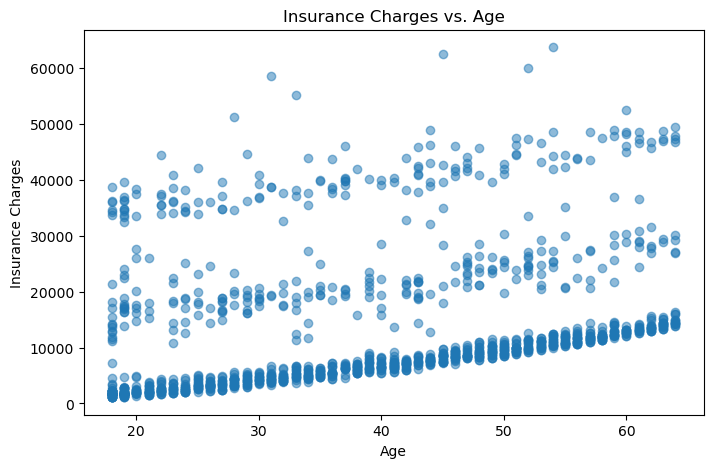

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(df["age"], df["charges"], alpha=0.5)
plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Insurance Charges vs. Age")
plt.show()


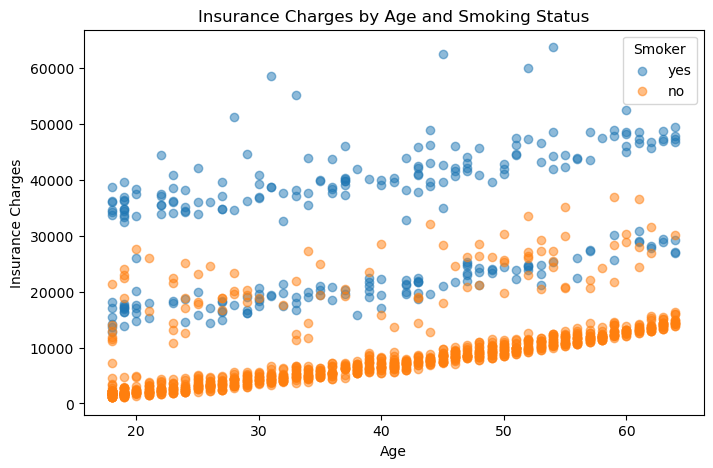

In [17]:
plt.figure(figsize=(8, 5))

for status in df["smoker"].unique():
    subset = df[df["smoker"] == status]
    plt.scatter(
        subset["age"],
        subset["charges"],
        alpha=0.5,
        label=status
    )

plt.xlabel("Age")
plt.ylabel("Insurance Charges")
plt.title("Insurance Charges by Age and Smoking Status")
plt.legend(title="Smoker")
plt.show()

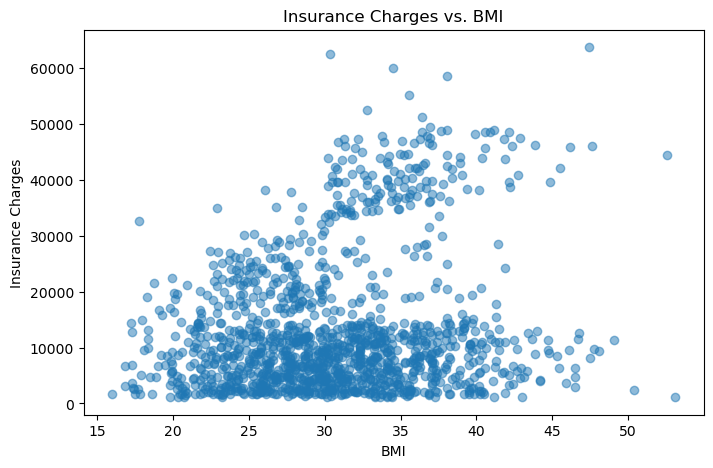

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["bmi"],
    df["charges"],
    alpha=0.5
)

plt.xlabel("BMI")
plt.ylabel("Insurance Charges")
plt.title("Insurance Charges vs. BMI")
plt.show()

<Figure size 800x500 with 0 Axes>

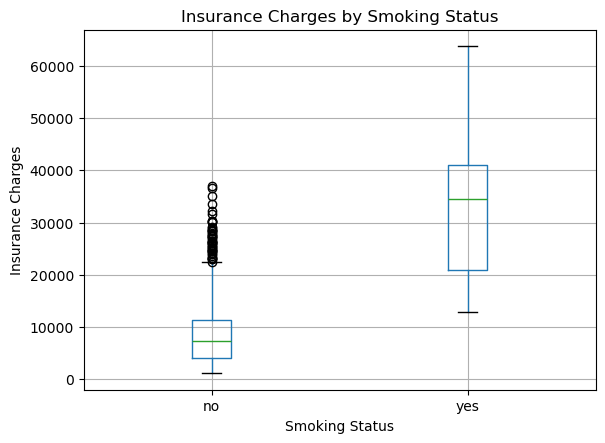

In [19]:
plt.figure(figsize=(8, 5))

df.boxplot(
    column="charges",
    by="smoker"
)

plt.title("Insurance Charges by Smoking Status")
plt.suptitle("")
plt.xlabel("Smoking Status")
plt.ylabel("Insurance Charges")
plt.show()

In [20]:
Q1 = df["charges"].quantile(0.25)
Q3 = df["charges"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", round(Q1, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))

Q1: 4746.34
Q3: 16657.72
IQR: 11911.37
Lower Bound: -13120.72
Upper Bound: 34524.78


In [21]:
outlier_count = (df["charges"] > upper_bound).sum()

print("Potential outliers:", outlier_count)
print("Percentage of dataset:", round(outlier_count / len(df) * 100, 2), "%")

Potential outliers: 139
Percentage of dataset: 10.4 %


In [22]:
outliers = df[df["charges"] > upper_bound]

print(outliers["smoker"].value_counts())

smoker
yes    136
no       3
Name: count, dtype: int64


In [23]:
outlier_smoker_pct = (
    (outliers["smoker"] == "yes").sum()
    / len(outliers)
    * 100
)

print("Percentage of potential outliers who are smokers:",
      round(outlier_smoker_pct, 2), "%")

Percentage of potential outliers who are smokers: 97.84 %


In [24]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[17, 29, 49, 64],
    labels=["Young Adult", "Adult", "Senior Adult"]
)

df["bmi_category"] = pd.cut(
    df["bmi"],
    bins=[0, 18.5, 25, 30, float("inf")],
    labels=["Underweight", "Normal", "Overweight", "Obese"],
    right=False
)

df["cost_segment"] = np.where(
    df["charges"] >= 30000,
    "High Cost",
    "Below 30000"
)

df.head()

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category,cost_segment
0,19,female,27.900,0,yes,southwest,16884.92400,Young Adult,Overweight,Below 30000
1,18,male,33.770,1,no,southeast,1725.55230,Young Adult,Obese,Below 30000
2,28,male,33.000,3,no,southeast,4449.46200,Young Adult,Obese,Below 30000
3,33,male,22.705,0,no,northwest,21984.47061,Adult,Normal,Below 30000
4,32,male,28.880,0,no,northwest,3866.85520,Adult,Overweight,Below 30000


In [25]:
df.to_csv("../data/processed/insurance_analysis_ready.csv", index=False)

In [26]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Missing values:")
print(df.isnull().sum())

Rows: 1337
Columns: 10
Missing values:
age             0
sex             0
bmi             0
children        0
smoker          0
region          0
charges         0
age_group       0
bmi_category    0
cost_segment    0
dtype: int64


In [27]:
Untitled.ipynb

NameError: name 'Untitled' is not defined